# 🎬 CineMatch AI-Movie Recommender System

### 551:Engineering Programming: Python
**Team Members:** Tushar Garje, Anil Telaprolu, Reshikesh Poreddy

---

## Project Overview

CineMatch AI is a content-based movie recommender system that helps users discover movies based on:
- **Genre preferences** — select genres you like
- **Plot description** — describe what you want to watch using natural language

The system uses TF-IDF vectorization and cosine similarity to match user queries against movie overviews and taglines.

---

## Tech Stack
| Tool | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data loading and preprocessing |
| Scikit-learn | TF-IDF vectorization and cosine similarity |
| Matplotlib | Data visualization |
| Streamlit | Web UI |
| Joblib | Model serialization |

## Step 1: Import Modules

In [2]:
# Standard libraries
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Project modules
from data_loader import load_movie_data
from classes.Movie import Movie
from classes.Recommender import Recommender


## Step 2: Load the Dataset

In [3]:
# Load cleaned movie dataset
df = load_movie_data()

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Total movies: {len(df)}')

df.head()

Dataset shape: (1060637, 5)
Columns: ['id', 'title', 'overview', 'tagline', 'genres']
Total movies: 1060637


,id,title,overview,tagline,genres
0,27205,Inception,"Cobb, a skilled thief who commits corporate es...",Your mind is the scene of the crime.,"Action, Science Fiction, Adventure"
1,157336,Interstellar,The adventures of a group of explorers who mak...,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction"
2,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,Welcome to a world without rules.,"Drama, Action, Crime, Thriller"
3,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction"
4,24428,The Avengers,When an unexpected enemy emerges and threatens...,Some assembly required.,"Science Fiction, Action, Adventure"


## Step 3: Data Summary & Statistics

In [4]:
# Basic statistics
print('Dataset Summary')
print(f'Total movies     : {len(df)}')
print(f'Missing overviews: {df["overview"].isna().sum()}')
print(f'Missing taglines : {df["tagline"].isna().sum()}')
print(f'Missing genres   : {df["genres"].isna().sum()}')

# Overview length distribution
df['overview_len'] = df['overview'].fillna('').apply(len)
print(f'\nAverage overview length: {df["overview_len"].mean():.0f} characters')
print(f'Max overview length    : {df["overview_len"].max()} characters')

Dataset Summary
Total movies     : 1060637
Missing overviews: 0
Missing taglines : 867167
Missing genres   : 420300

Average overview length: 271 characters
Max overview length    : 1000 characters


## Step 4: Genre Distribution (Matplotlib Visualization)

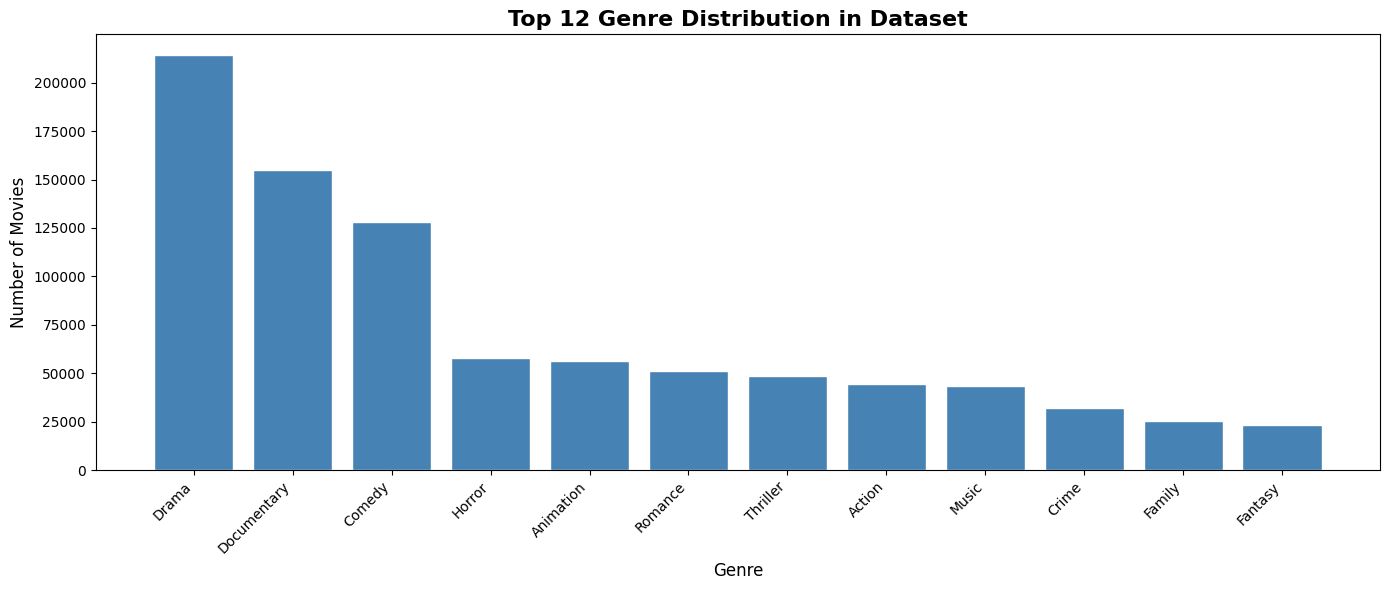

Total unique genres: 19


In [5]:
# Extract all genres using list comprehension (Part 2 requirement)
all_genres = [
    genre.strip()
    for genres in df['genres'].fillna('')
    for genre in genres.split(',')
    if genre.strip()
]

# Count genre frequencies
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(12))

# Plot bar chart
plt.figure(figsize=(14, 6))
plt.bar(top_genres.keys(), top_genres.values(), color='steelblue', edgecolor='white')
plt.title('Top 12 Genre Distribution in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique genres: {len(genre_counts)}')

## Step 5: Initialize the Recommender

In [6]:
# Initialize Recommender — fits TF-IDF on combined overview + tagline
print('Initializing Recommender...')
rec = Recommender(df)

print(f'Recommender ready!')
print(f'Total movies indexed: {len(rec)}')
print(f'TF-IDF matrix shape : {rec.tfidf_matrix.shape}')

Initializing Recommender...
Recommender ready!
Total movies indexed: 1060637
TF-IDF matrix shape : (1060637, 15000)


## Step 6: Genre-Based Recommendation

In [7]:
# Recommend movies by genre
selected_genres = ['Action', 'Sci-Fi']
print(f'Finding movies for genres: {selected_genres}\n')

genre_results = rec.recommend_by_genre(selected_genres, top_k=5)

for i, movie in enumerate(genre_results, 1):
    print(f'{i}. {movie}')  # Uses __str__
    print(f'   Overview : {movie.description[:120]}...')
    print(f'   Tagline  : {movie.tagline}')
    print()

Finding movies for genres: ['Action', 'Sci-Fi']

1. Inception (Action, Science Fiction, Adventure)
   Overview : Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chanc...
   Tagline  : Your mind is the scene of the crime.

2. The Dark Knight (Drama, Action, Crime, Thriller)
   Overview : Batman raises the stakes in his war on crime. With the help of Lt. Jim Gordon and District Attorney Harvey Dent, Batman ...
   Tagline  : Welcome to a world without rules.

3. Avatar (Action, Adventure, Fantasy, Science Fiction)
   Overview : In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between...
   Tagline  : Enter the world of Pandora.

4. The Avengers (Science Fiction, Action, Adventure)
   Overview : When an unexpected enemy emerges and threatens global safety and security, Nick Fury, director of the international peac...
   Tagline  : Some assembly required.

5. De

## Step 7: Plot-Based Recommendation (AI Search)

In [ ]:
# Recommend movies by plot description
query = 'space travel astronaut mission wormhole'
print(f'Finding movies for query: "{query}"\n')

plot_results = rec.recommend_by_description(query, top_k=5)

for i, movie in enumerate(plot_results, 1):
    print(f'{i}. {movie}')  
    print(f'   Overview : {movie.description[:120]}...')
    print(f'   Tagline  : {movie.tagline}')
    print()

Finding movies for query: "space travel astronaut mission wormhole"

1. Lost in Space (Drama)
   Overview : An astronaut's wife realizes he has changed after he returns from a famous space mission....
   Tagline  : 

2. A Grain in Space (Animation)
   Overview : An astronaut is unlucky in space....
   Tagline  : 

3. Void (Science Fiction)
   Overview : Void focuses on an astronaut from a parallel universe who travels to other worlds through a void in space. However, the ...
   Tagline  : 

4. Lost In Space ()
   Overview : Lost In Space is a silent space film where a astronaut gets lost in space on his space mission but ends up discovering a...
   Tagline  : Lost

5. Through the Eyes of an Astronaut (Documentary)
   Overview : Directed by Franco-German duo Pierre-Emmanuel Le Goff and Jürgen Hansen, Through the Eyes of an Astronaut is a 28-minute...
   Tagline  : 



## Step 8: Movie Class Demo — Operator Overloads

In [10]:
# Demonstrate Movie class features
m1 = Movie(1, 'Inception', 'Action, Sci-Fi', 'A thief who steals corporate secrets through dream-sharing.', 'Your mind is the scene of the crime.')
m2 = Movie(1, 'Inception Copy', 'Sci-Fi', 'Another description.', '')
m3 = Movie(2, 'Interstellar', 'Sci-Fi, Drama', 'A team travels through a wormhole in space.', 'Mankind was born on Earth.')

print('Movie Class Demo')
print(f'str(m1)              : {m1}')
print(f'len(m1)              : {len(m1)}')
print(f'm1 == m2 (same ID)   : {m1 == m2}')
print(f'm1 == m3 (diff ID)   : {m1 == m3}')
print(f'Genres of m1         : {m1.get_genre_list()}')
print(f'Genres of m3         : {m3.get_genre_list()}')

Movie Class Demo
str(m1)              : Inception (Action, Sci-Fi)
len(m1)              : 59
m1 == m2 (same ID)   : True
m1 == m3 (diff ID)   : False
Genres of m1         : ['Action', 'Sci-Fi']
Genres of m3         : ['Sci-Fi', 'Drama']


## Step 9: All Available Genres

In [11]:
# Get all unique genres using set operations
all_unique_genres = rec.get_all_genres()

print(f'Total unique genres: {len(all_unique_genres)}')
print(f'Genres: {all_unique_genres}')

Total unique genres: 19
Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


## Step 10: Exception Handling Demo

In [13]:
# Demo 1: FileNotFoundError
print('Exception Handling Demo')

try:
    load_movie_data('nonexistent_file.csv')
except FileNotFoundError as e:
    print(f'FileNotFoundError caught: {e}')

# Demo 2: Empty query ValueError
try:
    rec.recommend_by_description('   ')
except ValueError as e:
    print(f'ValueError caught      : {e}')

# Demo 3: Invalid genre type
try:
    rec.recommend_by_genre('Action')
except TypeError as e:
    print(f'TypeError caught       : {e}')

Exception Handling Demo
FileNotFoundError caught: Dataset file not found at path: 'nonexistent_file.csv'. Please ensure movies_clean.csv exists in the project root.
ValueError caught      : Query string cannot be empty.
TypeError caught       : selected_genres must be a list.


## Step 11: Overview Length Distribution (Histogram)

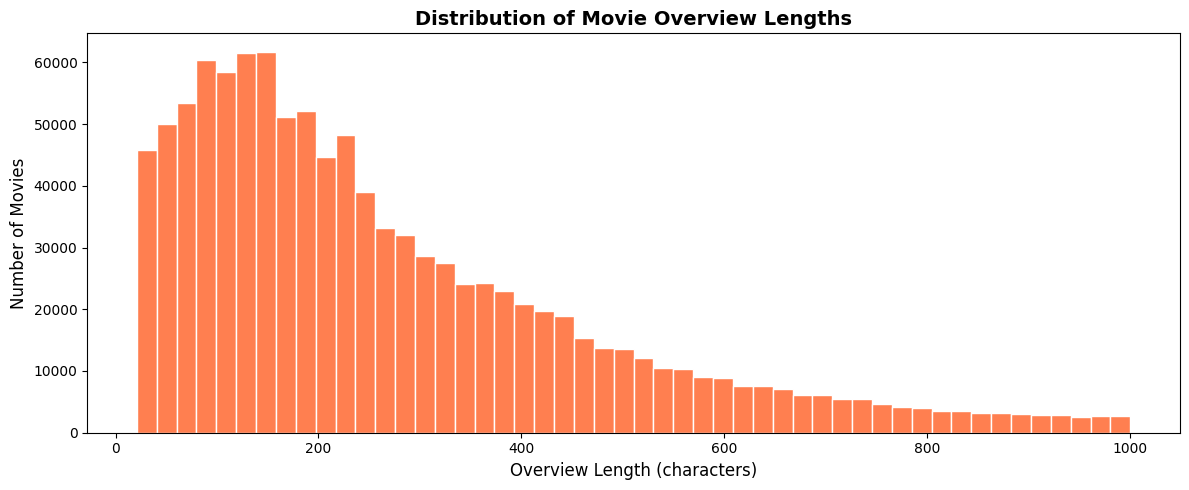

In [14]:
# Histogram of overview lengths
plt.figure(figsize=(12, 5))
plt.hist(df['overview_len'], bins=50, color='coral', edgecolor='white')
plt.title('Distribution of Movie Overview Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Overview Length (characters)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated:

| Feature | Details |
|---|---|
| Data Loading | CSV loaded via `data_loader.py` with error handling |
| Classes | `Movie` and `Recommender` with composition relationship |
| Operator Overloads | `__str__`, `__eq__`, `__len__` on `Movie` |
| TF-IDF Recommender | Genre-based and plot-based recommendations |
| Exception Handling | `FileNotFoundError`, `ValueError`, `TypeError` |
| Visualizations | Genre bar chart, overview length histogram |
| Part 2 Features | List comprehension, set operations, lambda, `__name__` |

**To run the full web app:**
```bash
python -m streamlit run app.py
```